In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
raw_fc_data = pd.read_csv("electricity_price_forecast_assignment-quant_assignment-data/data/data_forecast.csv")
raw_act_data = pd.read_csv("electricity_price_forecast_assignment-quant_assignment-data/data/data_actual.csv")

raw_fc_data["valuetime"] = pd.to_datetime(raw_fc_data["valuetime"])
raw_act_data["valuetime"] = pd.to_datetime(raw_act_data["valuetime"])

In [3]:
# Duplicated datasets

flag = any(raw_fc_data["valuetime"].duplicated())
print(f"Forcasted - Duplicated  timestamps: {flag}" )
flag = any(raw_act_data["valuetime"].duplicated())
print(f"Actual - Duplicated  timestamps: {flag}" )

Forcasted - Duplicated  timestamps: False
Actual - Duplicated  timestamps: False


In [4]:
# Timestamp continuity gaps

ts_rg = pd.date_range(start=raw_fc_data["valuetime"].min(), end= raw_fc_data["valuetime"].max(), freq ="h")

flag = len(ts_rg) != len(raw_fc_data)
print(f"Forcasted - Misisng  timestamps: {flag}" )
flag = len(ts_rg) != len(raw_act_data)
print(f"Actual - Misisng  timestamps: {flag}" )

Forcasted - Misisng  timestamps: False
Actual - Misisng  timestamps: False


In [5]:
# Checking NA

flag = raw_fc_data.isna().sum()
print(f"Forcasted - NA's present:\n{flag}")

flag = raw_act_data.isna().sum()
print(f"Actual - NA's  timestamps:\n{flag}")

Forcasted - NA's present:
valuetime    0
wind         0
solar        0
load         0
flow         0
dtype: int64
Actual - NA's  timestamps:
valuetime    0
wind         0
solar        0
load         0
spot         0
flow         0
dtype: int64


In [6]:
print("Forecast data stats")
print(raw_fc_data.describe())
print("Actual data stats")
print(raw_act_data.describe())

Forecast data stats
                 valuetime         wind        solar         load         flow
count                 2880  2880.000000  2880.000000  2880.000000  2880.000000
mean   2020-12-30 22:30:00  1475.695628    23.333464  2686.375261  1140.609222
min    2020-10-31 23:00:00    24.670000     0.000000  1630.969971 -2500.000000
25%    2020-11-30 22:45:00   592.130020     0.000000  2280.109924   638.940000
50%    2020-12-30 22:30:00  1387.584961     0.000000  2656.699951  1365.190000
75%    2021-01-29 22:15:00  2280.114990    13.975000  3115.310059  1874.190000
max    2021-02-28 22:00:00  3692.889893   371.989990  3794.360107  2500.000000
std                    NaN   974.738079    53.433750   486.583097  1081.625175
Actual data stats
                 valuetime         wind        solar         load  \
count                 2880  2880.000000  2880.000000  2880.000000   
mean   2020-12-30 22:30:00  1459.371404    23.762153  2699.929167   
min    2020-10-31 23:00:00    22.629999     

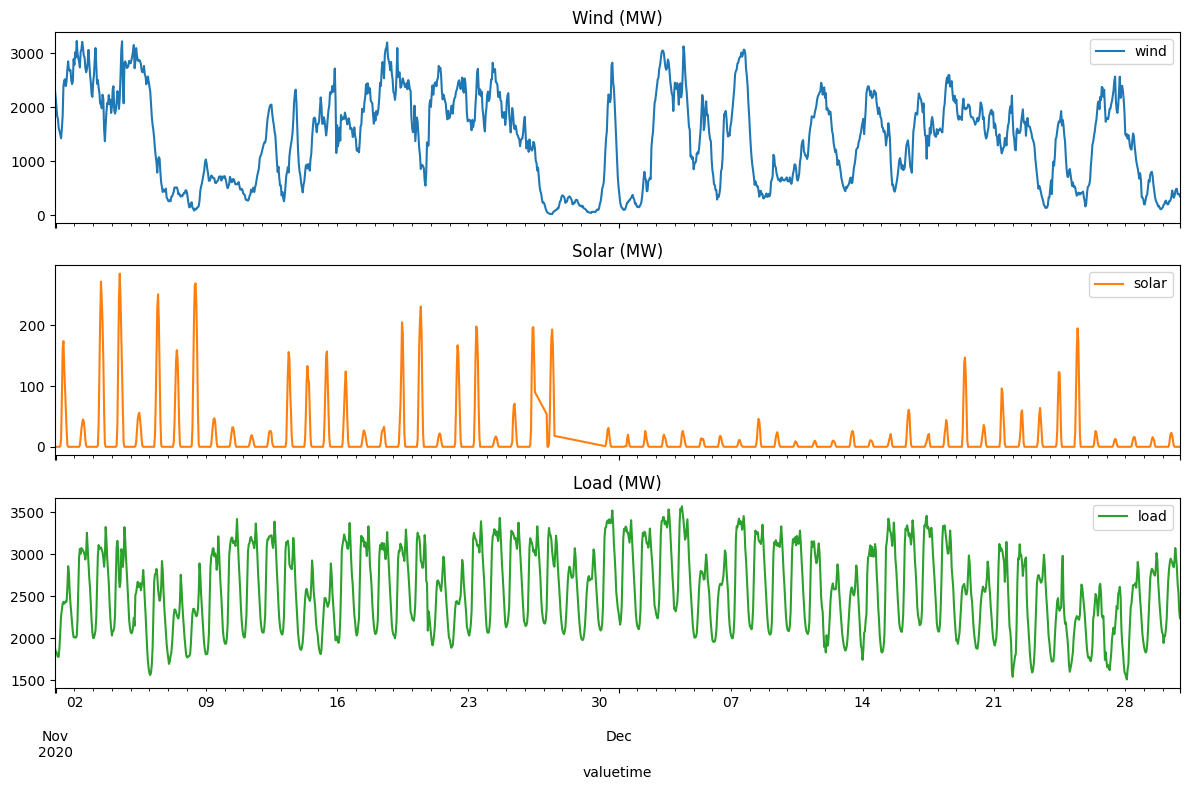

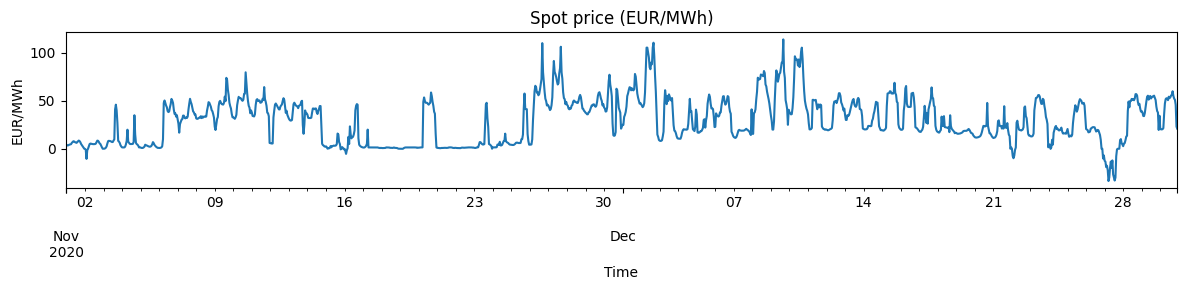

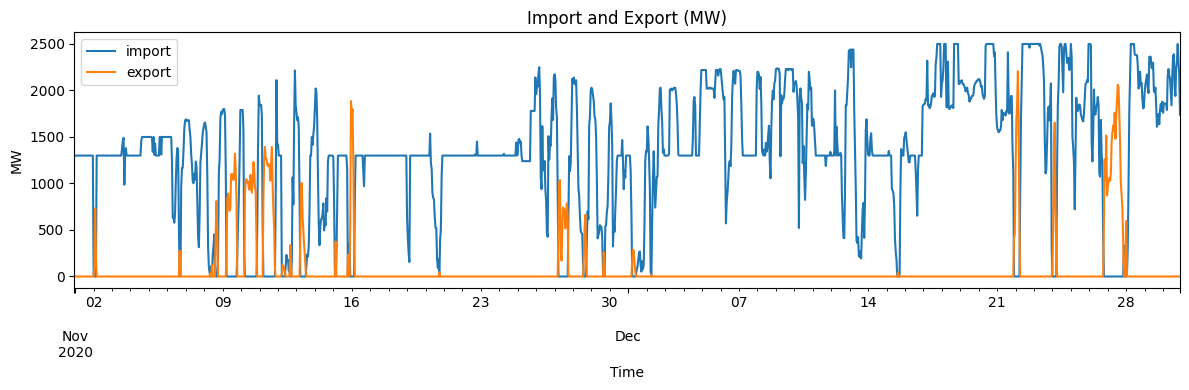

In [11]:
raw_act_data["import"] =raw_act_data["flow"].clip(lower=0)
raw_act_data["export"] = (-raw_act_data["flow"]).clip(lower=0)
train_data = raw_act_data[0:60*24]
test_data = raw_act_data[60*24:90*24]
validate_data = raw_act_data[90*24:]

df = train_data.copy(deep=True)
df.set_index("valuetime", inplace=True)
# 1) Wind, solar, load on aligned subplots
ax = df[["wind", "solar", "load"]].plot(subplots=True, figsize=(12, 8), sharex=True, title=["Wind (MW)", "Solar (MW)", "Load (MW)"])
plt.tight_layout()


# 2) Spot price
plt.figure(figsize=(12, 3))
df["spot"].plot()
plt.title("Spot price (EUR/MWh)")
plt.ylabel("EUR/MWh")
plt.xlabel("Time")
plt.tight_layout()

# 3) Import / export on the same axis
plt.figure(figsize=(12, 4))
df[["import", "export"]].plot(ax=plt.gca())
plt.title("Import and Export (MW)")
plt.ylabel("MW")
plt.xlabel("Time")
plt.tight_layout()

